In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.io
import os

In [2]:
def import_dataset(subject, rep, path):
    file_list = os.listdir(path)
    x_train = []
    input_shape = (16, 8, 1)

    for gesture in range(1, 9):
        if rep < 10:
            if subject < 10:
                globals()['data_S{}_G{}_R{}'.format(subject, gesture, rep)] = \
                scipy.io.loadmat(path + file_list[subject - 1] +
                                 '/00{}-00{}-00{}.mat'.format(subject, gesture, rep))['data']
            elif subject >= 10:
                globals()['data_S{}_G{}_R{}'.format(subject, gesture, rep)] = \
                scipy.io.loadmat(path + file_list[subject - 1] +
                                 '/0{}-00{}-00{}.mat'.format(subject, gesture, rep))['data']
            else:
                print(gesture, rep, "!!!!!!!!!!!!!!!!!!")

            data = globals()['data_S{}_G{}_R{}'.format(subject, gesture, rep)]
            #data = data[:, sel_four_ch]
            #print('before - ', data.shape)
            x_train.append(data)


        elif rep == 10:  # rep 10
            if subject < 10:
                globals()['data_S{}_G{}_R10'.format(subject, gesture)] = \
                scipy.io.loadmat(path + file_list[subject - 1] +
                                 '/00{}-00{}-010.mat'.format(subject, gesture))['data']
            elif subject >= 10:
                globals()['data_S{}_G{}_R10'.format(subject, gesture)] = \
                scipy.io.loadmat(path + file_list[subject - 1] +
                                 '/0{}-00{}-010.mat'.format(subject, gesture))['data']
            else:
                print(subject, rep, "!!!!!!!!!!!!!!!!!!!!!!!!")

            data = globals()['data_S{}_G{}_R10'.format(subject, gesture)]
            #data = data[:, sel_four_ch]

            x_train.append(data)

    return x_train

In [3]:
f_path = 'C:/Users/hml76/Desktop/Jupyter/Datasets/CapgMyo/DB_A_preproceesed/'

In [4]:
from scipy.fft import fft, fftfreq

# ----------------------------------------
# 1. Compute FFT for one dataset X
# ----------------------------------------

def compute_fft_stats(X, fs=1000):
    """
    X: list length 8 (classes), each element [time x channels] = (1000,128)

    Returns:
        freq_stats: {class: {channel: dict(mean, std, var, dom_freq)}}
    """
    num_classes = len(X)
    time_len, num_channels = X[0].shape

    freqs = fftfreq(time_len, 1/fs)
    pos_mask = freqs >= 0
    freqs = freqs[pos_mask]

    stats = {c: {} for c in range(num_classes)}

    for c in range(num_classes):
        cl_data = X[c]  # shape (1000,128)
        for ch in range(num_channels):

            sig = cl_data[:, ch]
            fft_val = np.abs(fft(sig))[pos_mask]

            stats[c][ch] = {
                "fft": fft_val,
                "mean": np.mean(fft_val),
                "std": np.std(fft_val),
                "var": np.var(fft_val),
                "dom_freq": freqs[np.argmax(fft_val)]
            }

    return freqs, stats


# ---------------------------------------------------------
# 2. Aggregate FFT stats across repetitions per subject
# ---------------------------------------------------------

def aggregate_reps(subject_id, f_path, import_dataset):
    """
    Returns aggregated stats averaged across 10 repetitions for one subject.
    """
    rep_stats = []

    for rep in range(1, 11):
        X = import_dataset(subject=subject_id, rep=rep, path=f_path)
        freqs, stats = compute_fft_stats(X)
        rep_stats.append(stats)

    num_classes = len(rep_stats[0])
    num_channels = len(rep_stats[0][0])

    agg = {c: {} for c in range(num_classes)}

    for c in range(num_classes):
        for ch in range(num_channels):
            # Stack all fft vectors from 10 repetitions
            fft_stack = np.array([rep_stats[r][c][ch]["fft"] for r in range(10)])

            agg[c][ch] = {
                "mean_fft": np.mean(fft_stack, axis=0),
                "std_fft": np.std(fft_stack, axis=0),
                "var_fft": np.var(fft_stack, axis=0),
                "dom_freq": freqs[np.argmax(np.mean(fft_stack, axis=0))]
            }

    return freqs, agg


# -----------------------------------------------------------------
# 3. Aggregate again across all 10 subjects (final average FFT)
# -----------------------------------------------------------------

def aggregate_subjects(f_path, import_dataset):
    all_subject_stats = []

    for sub in range(1, 11):
        freqs, stats = aggregate_reps(sub, f_path, import_dataset)
        all_subject_stats.append(stats)

    num_classes = len(all_subject_stats[0])
    num_channels = len(all_subject_stats[0][0])

    final_agg = {c: {} for c in range(num_classes)}

    for c in range(num_classes):
        for ch in range(num_channels):

            fft_stack = np.array([
                all_subject_stats[sub][c][ch]["mean_fft"] for sub in range(10)
            ])

            final_agg[c][ch] = {
                "mean_fft": np.mean(fft_stack, axis=0),
                "std_fft": np.std(fft_stack, axis=0),
                "var_fft": np.var(fft_stack, axis=0),
                "dom_freq": freqs[np.argmax(np.mean(fft_stack, axis=0))]
            }

    return freqs, final_agg

In [5]:
freqs, final_stats = aggregate_subjects(f_path, import_dataset)

In [6]:
def plot_subject_fft(freqs, stats, subject_id, max_freq=300):
    """
    stats: result from aggregate_reps() for one subject
    """

    num_classes = len(stats)
    num_channels = len(stats[0])

    for c in range(num_classes):
        plt.figure(figsize=(10,5))
        for ch in range(num_channels):
            mean_fft = stats[c][ch]["mean_fft"]
            std_fft  = stats[c][ch]["std_fft"]
            dom_freq = stats[c][ch]["dom_freq"]

            plt.plot(freqs, mean_fft, alpha=0.3)
            plt.fill_between(freqs, mean_fft-std_fft, mean_fft+std_fft, alpha=0.08)
            plt.axvline(dom_freq, color='r', linestyle='--', alpha=0.4)

        plt.xlim([0, max_freq])
        plt.title(f"Subject {subject_id} — Class {c} Mean FFT ± STD")
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("Magnitude")
        plt.grid(True)
        plt.show()


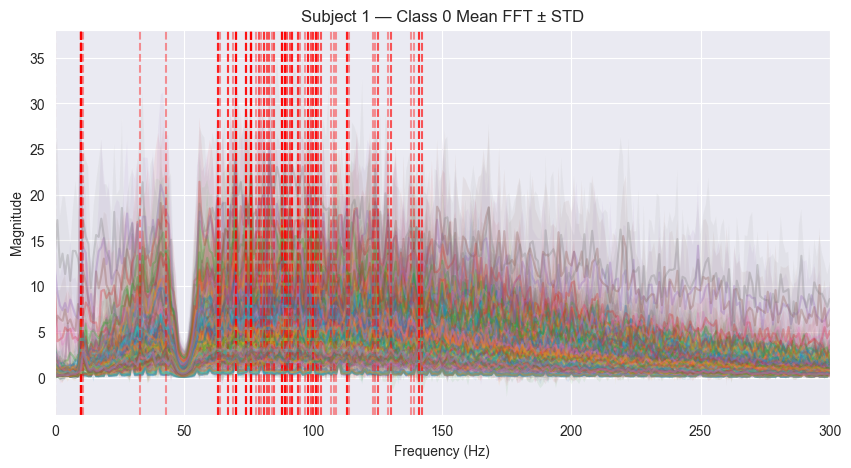

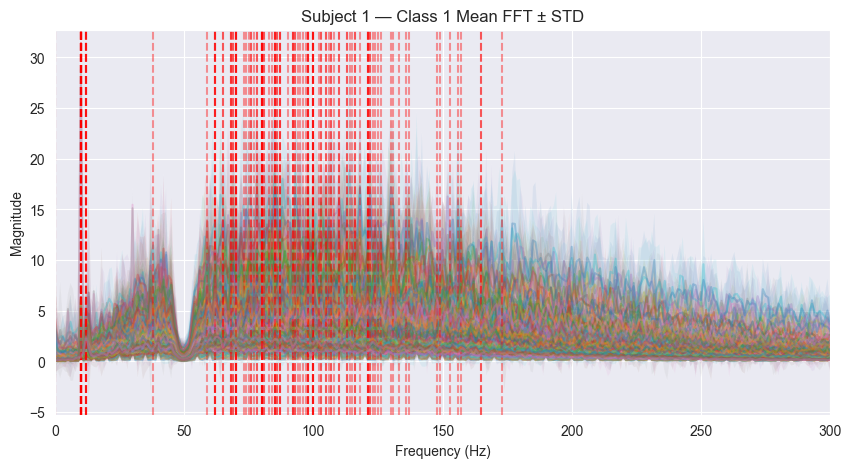

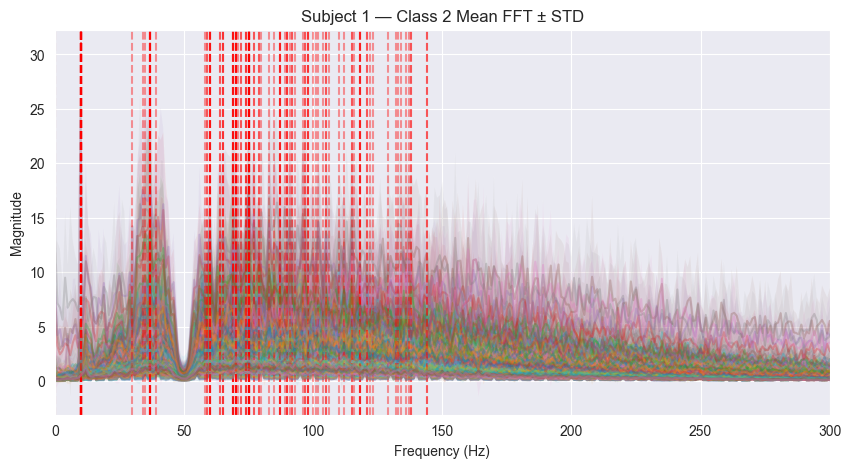

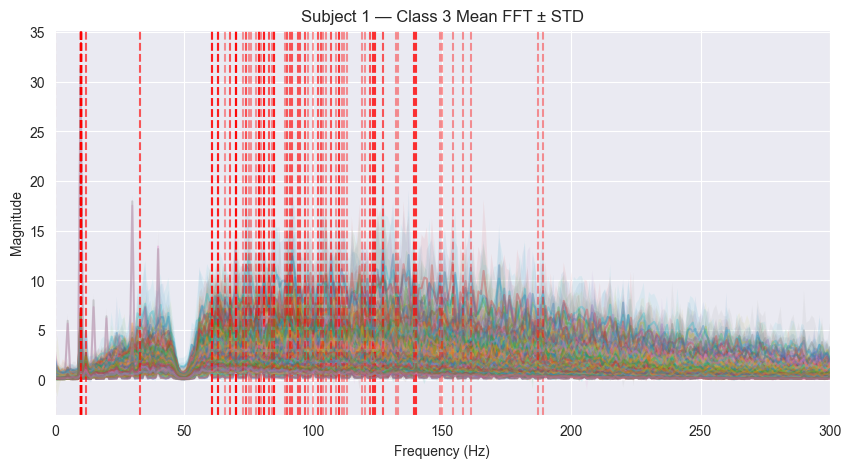

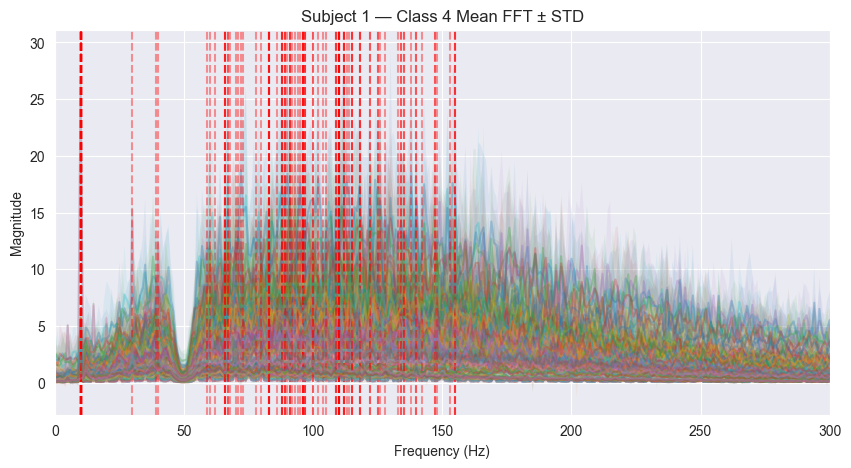

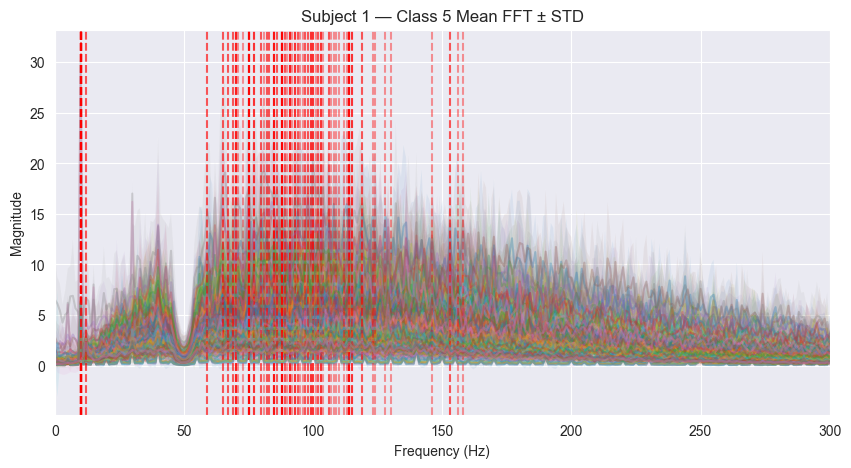

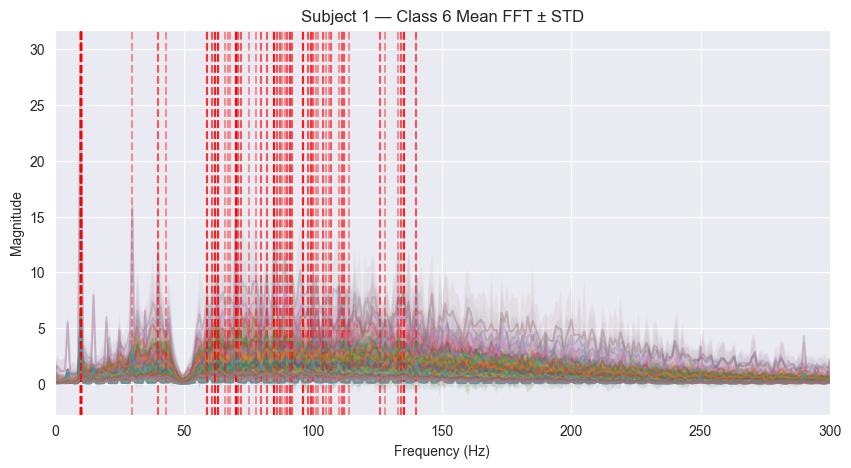

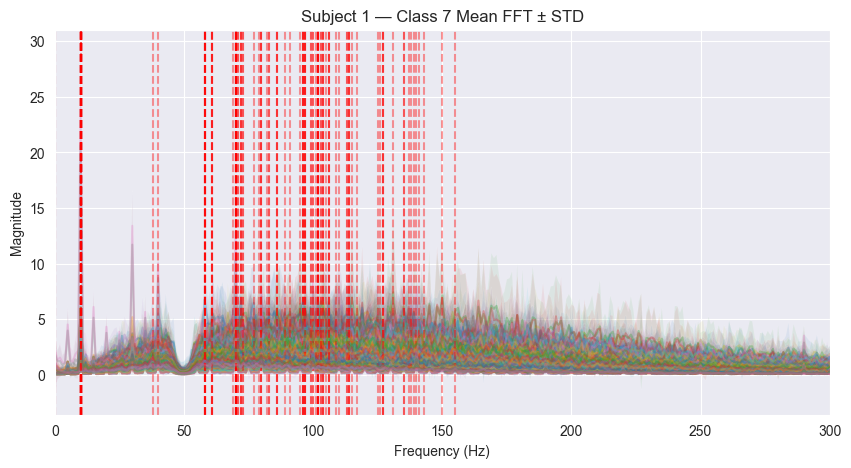

In [7]:
freqs, stats_sub = aggregate_reps(1, f_path, import_dataset)
plot_subject_fft(freqs, stats_sub, subject_id=1)

In [8]:
def compute_global_dom_freq_stats(final_stats):
    """
    final_stats: structure like final_stats[class][channel]["dom_freq"]

    Returns:
        global_mean, global_std, matrix (class x channel)
    """
    num_classes = len(final_stats)
    num_channels = len(final_stats[0])

    # Extract into a matrix
    dom_matrix = np.zeros((num_classes, num_channels))

    for c in range(num_classes):
        for ch in range(num_channels):
            dom_matrix[c, ch] = final_stats[c][ch]["dom_freq"]

    # Flatten across class × channel
    all_dom = dom_matrix.flatten()

    global_mean = np.mean(all_dom)
    global_std  = np.std(all_dom)

    return global_mean, global_std, dom_matrix


In [9]:
global_mean, global_std, dom_matrix = compute_global_dom_freq_stats(final_stats)

print("Global Mean Dominant Frequency:", global_mean)
print("Global STD  Dominant Frequency:", global_std)


Global Mean Dominant Frequency: 43.044921875
Global STD  Dominant Frequency: 44.60862722221058
